#Task 1: Acquire, preprocess, and analyze the data

importing libraries

In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.preprocessing import StandardScaler

##Dataset 1: Heart Disease:

In [483]:
# for the heart dataset
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [484]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X_heart = heart_disease.data.features
# Thetarget variable represents absence with a value of 0 and presence with a non-zero value (i.e., 1, 2, 3, or 4).
Y_heart = heart_disease.data.targets

# Merge datasets with target column at the end (this is to make manipulating easier)
heart_df = pd.concat([X_heart, Y_heart], axis=1)
heart_df.rename(columns={'num': 'target'}, inplace=True)


In [485]:
# check for missing values
missing = heart_df.isnull().sum()

#Remove the rows with missing cells
heart_df = heart_df.dropna()

# Checking the shape of data
print(heart_df.shape)

#filter out if sex isn't 0 or 1
heart_df = heart_df[heart_df['sex'].isin([0, 1])]


# Filter targets not in 0-4
heart_df = heart_df[heart_df['target'].isin([0, 1, 2, 3, 4])]

# Update the target column: Convert 1-4 to 1
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x in [1, 2, 3, 4] else 0)

print(heart_df.head(5))

#calculate distribution:
print(heart_df['target'].value_counts(normalize=True) * 100)


(297, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0  2.30000      3   
1   67    1   4       160   286    0        2      108      1  1.50000      2   
2   67    1   4       120   229    0        2      129      1  2.60000      2   
3   37    1   3       130   250    0        0      187      0  3.50000      3   
4   41    0   2       130   204    0        2      172      0  1.40000      1   

       ca    thal  target  
0 0.00000 6.00000       0  
1 3.00000 3.00000       1  
2 2.00000 7.00000       1  
3 0.00000 3.00000       0  
4 0.00000 3.00000       0  
target
0   53.87205
1   46.12795
Name: proportion, dtype: float64


In [486]:
#seperate categorical features

# List of categorical features, according to the documentation
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

# Create a DataFrame with only the categorical features
categ_df = heart_df[categorical_features].drop(columns='target')

# Create a DataFrame with only the non-categorical features (exclude the categorical ones)
int_df = heart_df.drop(columns=categorical_features)



#find correlation for numerical
numerical_corr = int_df.corrwith(heart_df['target'])

#find correlation for categorical
categorical_corr = categ_df.corrwith(heart_df['target'])

heart_df_no_target = heart_df.drop(columns='target')

#find correlation for mixed
mixed_corr = heart_df_no_target.corrwith(heart_df['target'])


print("Average correlation (Numerical):", numerical_corr.abs().mean())
print("Average correlation (Categorical):", categorical_corr.abs().mean())
print("Average correlation (Mixed):", mixed_corr.abs().mean())



Average correlation (Numerical): 0.29531794621635865
Average correlation (Categorical): 0.3054236966485619
Average correlation (Mixed): 0.3007595041413912


now I'm scaling the non-categorical features

In [487]:
#scaler = StandardScaler()
#int_df = pd.DataFrame(scaler.fit_transform(int_df), columns=int_df.columns)

#int_df['target'] = categ_df['target'] #add the target column after scaling because it shouldn't be included in our calculations???
#print(int_df.head(5))



The percentage of men who have heart disease is 55.72139303482587
The percentage of women who have heart diseas is 26.041666666666668


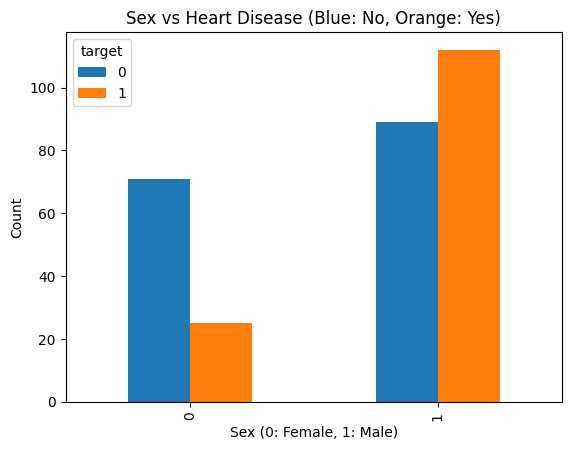

In [488]:
# Count occurrences of each combination of sex and heart disease
counts = heart_df.groupby(['sex', 'target']).size().unstack()

sum = (counts.sum(axis=1))
#calculate % heart disease (positive) for men vs for women:
pos_women = counts[1][0]
pos_men = counts[1][1]

percent_women = (pos_women/sum[0])*100
percent_men = (pos_men/sum[1])*100

print(f"The percentage of men who have heart disease is {percent_men}")
print(f"The percentage of women who have heart diseas is {percent_women}")


# Create a bar plot
counts.plot(kind='bar', stacked=False)

# Add labels and title
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Count')
plt.title('Sex vs Heart Disease (Blue: No, Orange: Yes)')

# Display the plot
plt.show()

The percentage of fbs who have heart disease is 46.51162790697674
The percentage of neg fbs who have heart diseas is 46.06299212598425


Text(0.5, 1.0, 'fbs vs Heart Disease (Blue: No, Orange: Yes)')

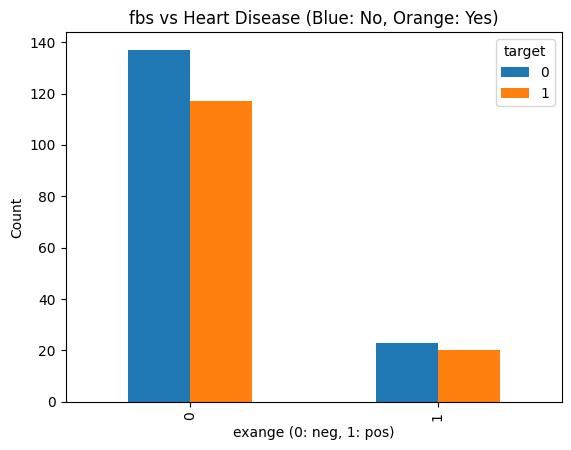

In [489]:
# Count occurrences of each combination of sex and heart disease
counts = heart_df.groupby(['fbs', 'target']).size().unstack()

sum = (counts.sum(axis=1))
#calculate % heart disease (positive) for men vs for women:
px = counts[1][0]
py = counts[1][1]

p1 = (px/sum[0])*100
p2 = (py/sum[1])*100

print(f"The percentage of fbs who have heart disease is {p2}")
print(f"The percentage of neg fbs who have heart diseas is {p1}")


# Create a bar plot
counts.plot(kind='bar', stacked=False)

# Add labels and title
plt.xlabel('exange (0: neg, 1: pos)')
plt.ylabel('Count')
plt.title('fbs vs Heart Disease (Blue: No, Orange: Yes)')

# Display the plot

It looks like the percentages of those with heart disease with fbs vs without fbs seem pretty similar, so this is not an affecting factor. This is confirmed by the chi-square test later on.


The percentage of posexang who have heart disease is 76.28865979381443
The percentage of negexang who have heart diseas is 31.5


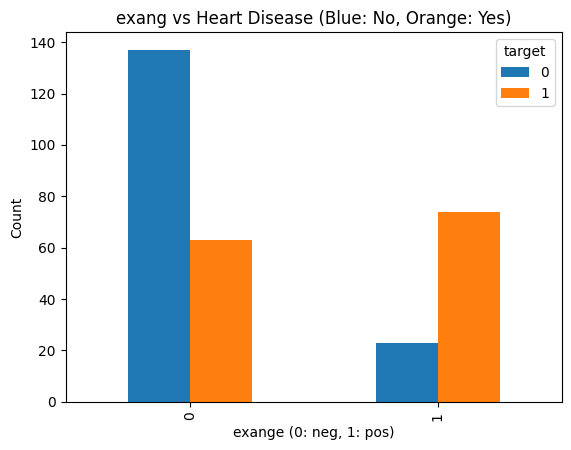

In [490]:
# Count occurrences of each combination of sex and heart disease
counts = heart_df.groupby(['exang', 'target']).size().unstack()

sum = (counts.sum(axis=1))
#calculate % heart disease (positive) for men vs for women:
pos_exang0 = counts[1][0]
pos_exang1 = counts[1][1]

p1 = (pos_exang0/sum[0])*100
p2 = (pos_exang1/sum[1])*100

print(f"The percentage of posexang who have heart disease is {p2}")
print(f"The percentage of negexang who have heart diseas is {p1}")


# Create a bar plot
counts.plot(kind='bar', stacked=False)

# Add labels and title
plt.xlabel('exange (0: neg, 1: pos)')
plt.ylabel('Count')
plt.title('exang vs Heart Disease (Blue: No, Orange: Yes)')

# Display the plot
plt.show()

In [491]:
##attempting chi-square to see if it can help me

from scipy.stats import chi2_contingency

p_values = {}
for column in categ_df.columns:
    if column != 'target':
        # create contingency table between the feature and the target (frequency of the column vs target)
        contingency_table = pd.crosstab(categ_df[column], heart_df['target'])
        chi2, p, _, _ = chi2_contingency(contingency_table)

        #put the p value in the table
        p_values[column] = p

# Select features with p-value less than 0.05 (or your chosen threshold)
significant_features = [feature for feature, p_value in p_values.items() if p_value < 0.05]
print(f"Significant features: {significant_features}")



Significant features: ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal']


Now, for the non-categorical features, I'm calculating the difference of means. It doesn't make sense to do this for the categorical features.

In [492]:
int_df['target'] = heart_df['target']

means_by_target = int_df.groupby('target').mean()
neg_int = means_by_target.loc[0]
pos_int = means_by_target.loc[1]


diff_int = (pos_int - neg_int)**2
print(diff_int)


age         16.93630
trestbps    29.81200
chol        69.89402
thalach    379.14947
oldpeak      0.98070
ca           0.75862
dtype: float64


FEATURES I'M REMOVING BECAUSE THEY SEEM IRRELEVANT:
1. From categorical: fbs, target, sex, restecg
2. From numbers: ca, oldpeak

According to reaserch paper:
age, ca, oldpeak, fbs, sex, restbp, restecg

In [493]:
df1 = categ_df.drop(columns=['fbs', 'sex', 'restecg'])
df2 = int_df.drop(columns=['ca', 'age', 'oldpeak'])

df1 = df1.reset_index(drop=True)
df2 = df2.reset_index(drop=True)


y_heart_final = heart_df['target']
x_heart_final = pd.concat([df1, df2], axis=1)

df2.drop(columns=['target'], inplace=True)
x_heart_final.drop(columns=['target'], inplace=True)



##Dataset 2: Penguin Dataset: (Update the file path accordingly)

###Acquire

In [494]:
penguin_data_file_path = "/content/drive/MyDrive/COMP551/penguins_size.csv"
penguin_data = pd.read_csv(penguin_data_file_path)

print(penguin_data.head())
print(penguin_data.shape)
# print((penguin_data['species']).unique())

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen          39.10000         18.70000          181.00000   
1  Adelie  Torgersen          39.50000         17.40000          186.00000   
2  Adelie  Torgersen          40.30000         18.00000          195.00000   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen          36.70000         19.30000          193.00000   

   body_mass_g     sex  
0   3750.00000    MALE  
1   3800.00000  FEMALE  
2   3250.00000  FEMALE  
3          NaN     NaN  
4   3450.00000  FEMALE  
(344, 7)


In [495]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Preprocessing

In [496]:
# Remove the island feature
penguin_data = penguin_data.drop(columns=['island'])

In [497]:
# check for missing values
missing_values = penguin_data.isnull().sum()
print(missing_values)

# Remove the rows with missing cells
penguin_data = penguin_data.dropna()

# Checking the shape of data
print(penguin_data.shape) # as assumed we removed one column and the ten rows of missing info

species               0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64
(334, 6)


Should we even do this??????
Convert the categorical features to numerical values

In [498]:
# check for the unique values in the col sex
print(penguin_data['sex'].unique())

# Clean and filter the "sex" column to include only MALE and FEMALE values
penguin_data = penguin_data[penguin_data['sex'].isin(['MALE', 'FEMALE'])]

# One hot encoing + removing one fo the columns to avoid multicollinearity
penguin_data = pd.get_dummies(penguin_data, columns=['sex'], drop_first=True)


print(penguin_data.shape)

['MALE' 'FEMALE' '.']
(333, 6)


In [499]:
print(penguin_data.head())

  species  culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0  Adelie          39.10000         18.70000          181.00000   3750.00000   
1  Adelie          39.50000         17.40000          186.00000   3800.00000   
2  Adelie          40.30000         18.00000          195.00000   3250.00000   
4  Adelie          36.70000         19.30000          193.00000   3450.00000   
5  Adelie          39.30000         20.60000          190.00000   3650.00000   

   sex_MALE  
0      True  
1     False  
2     False  
4     False  
5      True  


Split data into features and target values

In [500]:
X_penguin = penguin_data.drop(columns=['species'])
y_penguin = penguin_data['species']

###Analysis

In [501]:
# Calculate the mean of each feature for eahc of the type of species
species_means = penguin_data.groupby('species').mean()
print(species_means)


# Just to be easy to compare the values without the scientific notations
pd.set_option('display.float_format', '{:.5f}'.format)

# Using the means calculate the squared difference for each pair for each feature
species_keys = species_means.index
squared_diff_results = {}

for i in range(len(species_keys)):
    for j in range(i + 1, len(species_keys)):
        species_1 = species_keys[i]
        species_2 = species_keys[j]
        squared_diff = (species_means.loc[species_1] - species_means.loc[species_2]) ** 2
        squared_diff_results[f"{species_1} vs {species_2}"] = squared_diff

        print(f"{species_1} vs {species_2}:\n{squared_diff}\n")

           culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
species                                                                        
Adelie             38.82397         18.34726          190.10274   3706.16438   
Chinstrap          48.83382         18.42059          195.82353   3733.08824   
Gentoo             47.56807         14.99664          217.23529   5092.43697   

           sex_MALE  
species              
Adelie      0.50000  
Chinstrap   0.50000  
Gentoo      0.51261  
Adelie vs Chinstrap:
culmen_length_mm    100.19712
culmen_depth_mm       0.00538
flipper_length_mm    32.72743
body_mass_g         724.89379
sex_MALE              0.00000
dtype: float64

Adelie vs Gentoo:
culmen_length_mm         76.45919
culmen_depth_mm          11.22667
flipper_length_mm       736.17551
body_mass_g         1921751.69719
sex_MALE                  0.00016
dtype: float64

Chinstrap vs Gentoo:
culmen_length_mm          1.60214
culmen_depth_mm          11.72343
flipper_l

In [502]:
# Removing the sex feature
penguin_data = penguin_data.drop(columns=['sex_MALE'])

X_penguin = penguin_data.drop(columns=['species'])
y_penguin = penguin_data['species']

###Visualisation

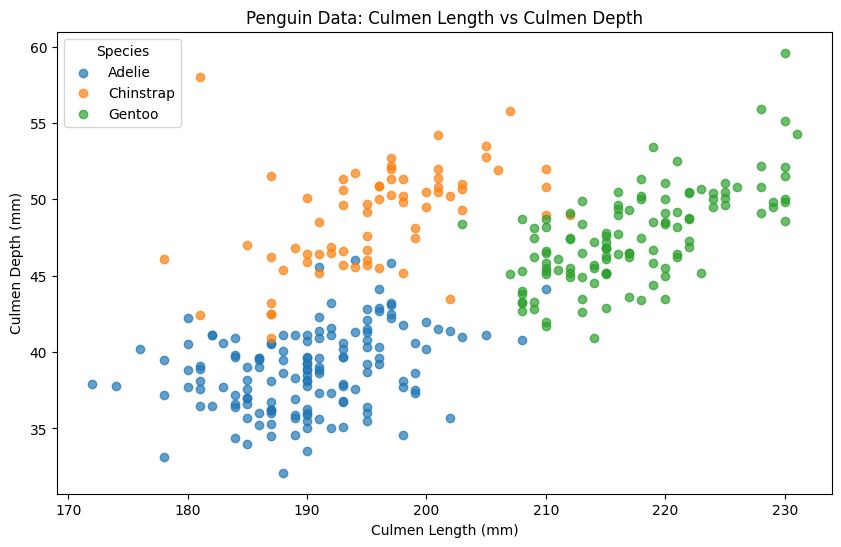

In [503]:
plt.figure(figsize=(10, 6))
for species in y_penguin.unique():
    subset = penguin_data[penguin_data['species'] == species]
    plt.scatter(subset['flipper_length_mm'], subset['culmen_length_mm'], label=species, alpha=0.7)
plt.xlabel("Culmen Length (mm)")
plt.ylabel("Culmen Depth (mm)")
plt.title("Penguin Data: Culmen Length vs Culmen Depth")
plt.legend(title="Species")
plt.show()

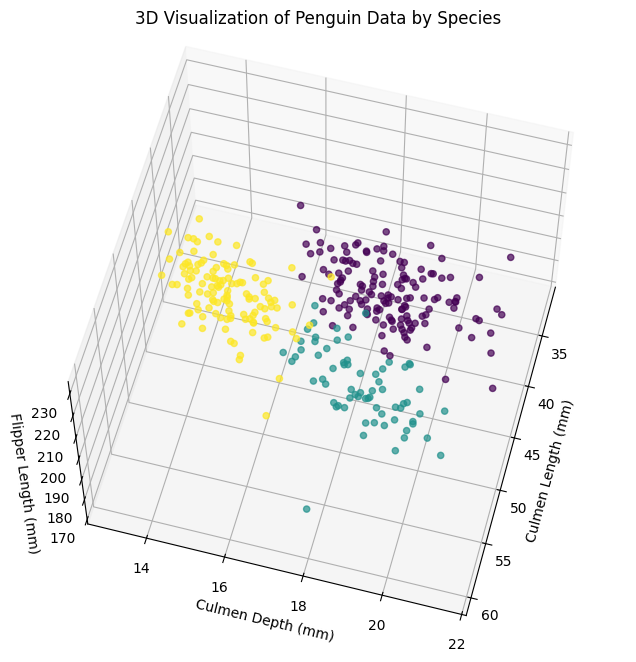

In [504]:
# this cell is copied from internet :D and it's only for trying out things
from mpl_toolkits.mplot3d import Axes3D

# 3D Visualization for Penguin Dataset
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the data
species_colors = y_penguin.astype('category').cat.codes  # Convert species to numerical for coloring
ax.scatter(X_penguin['culmen_length_mm'], X_penguin['culmen_depth_mm'], X_penguin['flipper_length_mm'],
           c=species_colors, cmap='viridis', alpha=0.7)
ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Culmen Depth (mm)")
ax.set_zlabel("Flipper Length (mm)")
ax.set_title("3D Visualization of Penguin Data by Species")

# Set view angle
ax.view_init(elev=60, azim=15)

plt.show()

#Task 2: Implementing KNN and DT and Task 3: Running experiments

##KNN

In [505]:
import builtins

class KNN:
    def __init__(self, k, distance_fn, weighted=False):
        self.k = k
        self.distance_fn = distance_fn
        self.weighted = weighted

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.array(y).flatten()

    def _distance(self, x1, x2):
        if self.distance_fn == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_fn == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Invalid distance function")

    def predict(self, X, use_probability=False):
        y_pred = []

        for x in X:
            # Calculate the distance of all points in the train from the given point in test
            distances = [self._distance(x, x_train) for x_train in self.X_train]

            # sort the distance and get the k nearest of them to our point
            KNN = np.argsort(distances)[:self.k]
            # liss the labels of those k nearest labels
            KNN_labels = [self.y_train[i] for i in KNN]

            # for closer data points to get more weight we use weighted avg
            if self.weighted:
                # To avoid dividing by zero we add a small value to the denom.
                weights = 1 / (np.array(distances)[KNN] + 1e-10)
                weighted_labels = {}
                # going through the knn we add their weight to the corresponding label and then we get the label with max weight
                for label, weight in zip(KNN_labels, weights):
                    if label not in weighted_labels:
                        weighted_labels[label] = 0
                    weighted_labels[label] += weight
                prediction = max(weighted_labels, key=weighted_labels.get)
                # Calculate the probability for the predictions
                probability = weighted_labels.get(1, 0) / builtins.sum(weighted_labels.values())

            else:
                # if we don't consider the distances and assume same weight for all the k points then just the max
                # y_pred.append(np.argmax(np.bincount(KNN_labels))) (this doesn't work for some ungodly reason)
                prediction = max(set(KNN_labels), key=KNN_labels.count)
                probability = KNN_labels.count(prediction) / self.k

            #TODO: implement the probability
            if use_probability:
                y_pred.append(probability)
            else:
                y_pred.append(prediction)

        return y_pred

In [506]:
# Evaluate model acuracy
def evaluate_acc(y_pred, y_test):
    return accuracy_score(y_test, y_pred)

In [507]:
#Normalize the datasets
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_penguin = scalar.fit_transform(X_penguin)
x_heart_final = scalar.fit_transform(x_heart_final)
df1 = scalar.fit_transform(df1)
df2 = scalar.fit_transform(df2)
X_heart_final = scalar.fit_transform(X_heart)

In [508]:
#Split the data for heart
# !!!!! Can we use sklearn here?!!!

from sklearn.model_selection import train_test_split
X_heart_train, X_heart_test, y_heart_train, y_heart_test = \
    train_test_split(x_heart_final, y_heart_final, test_size=0.4, random_state=11)

X_heart_train, X_heart_valid, y_heart_train, y_heart_valid = \
    train_test_split(X_heart_train, y_heart_train, test_size=0.2, random_state=11)

In [509]:
#JUST CATEGORICAL heart

#from sklearn.model_selection import train_test_split
#X_heart_train, X_heart_test, y_heart_train, y_heart_test = \
    #train_test_split(df1, y_heart_final, test_size=0.4, random_state=11)

#X_heart_train, X_heart_valid, y_heart_train, y_heart_valid = \
    #train_test_split(X_heart_train, y_heart_train, test_size=0.2, random_state=11)


In [510]:
#JUST NUMBERS heart (NOT CATEGORICAL)
#from sklearn.model_selection import train_test_split
#X_heart_train, X_heart_test, y_heart_train, y_heart_test = \
    #train_test_split(df2, y_heart_final, test_size=0.4, random_state=11)

#X_heart_train, X_heart_valid, y_heart_train, y_heart_valid = \
    #train_test_split(X_heart_train, y_heart_train, test_size=0.2, random_state=11)


In [511]:
#ALL DATA PENGUIN
#Split data for penguin

X_penguin_train, X_penguin_test, y_penguin_train, y_penguin_test = \
    train_test_split(X_penguin, y_penguin, test_size=0.4, random_state=11)

X_penguin_train, X_penguin_valid, y_penguin_train, y_penguin_valid = \
    train_test_split(X_penguin_train, y_penguin_train,  test_size=0.2, random_state=11)


In [512]:
print("Heart Disease Dataset:\n")
for k in range(1,11):
    knn = KNN(k=k, distance_fn='euclidean')
    knn.fit(X_heart_train, y_heart_train)
    y_valid_pred = knn.predict(X_heart_valid)
    y_test_pred = knn.predict(X_heart_test)
    # print(y_heart_valid.shape)
    # print(y_hvalid_pred.shape)
    valid_acc = evaluate_acc(y_heart_valid, y_valid_pred)
    test_acc = evaluate_acc(y_heart_test, y_test_pred)
    print(f"K={k}: Validation Accuracy = {valid_acc:.2f}, Test Accuracy = {test_acc:.2f}")

Heart Disease Dataset:

K=1: Validation Accuracy = 0.78, Test Accuracy = 0.67
K=2: Validation Accuracy = 0.78, Test Accuracy = 0.66
K=3: Validation Accuracy = 0.81, Test Accuracy = 0.72
K=4: Validation Accuracy = 0.81, Test Accuracy = 0.72
K=5: Validation Accuracy = 0.89, Test Accuracy = 0.76
K=6: Validation Accuracy = 0.83, Test Accuracy = 0.77
K=7: Validation Accuracy = 0.86, Test Accuracy = 0.76
K=8: Validation Accuracy = 0.83, Test Accuracy = 0.78
K=9: Validation Accuracy = 0.86, Test Accuracy = 0.74
K=10: Validation Accuracy = 0.83, Test Accuracy = 0.74


In [513]:
print("Heart Disease Dataset with weighted avg:\n")
for k in range(1,11):
    knn = KNN(k=k, distance_fn='euclidean', weighted=True)
    knn.fit(X_heart_train, y_heart_train)
    y_valid_pred = knn.predict(X_heart_valid)
    y_test_pred = knn.predict(X_heart_test)
    # print(y_heart_valid.shape)
    # print(y_hvalid_pred.shape)
    valid_acc = evaluate_acc(y_heart_valid, y_valid_pred)
    test_acc = evaluate_acc(y_heart_test, y_test_pred)
    print(f"K={k}: Validation Accuracy = {valid_acc:.2f}, Test Accuracy = {test_acc:.2f}")

Heart Disease Dataset with weighted avg:

K=1: Validation Accuracy = 0.78, Test Accuracy = 0.67
K=2: Validation Accuracy = 0.78, Test Accuracy = 0.67
K=3: Validation Accuracy = 0.78, Test Accuracy = 0.71
K=4: Validation Accuracy = 0.78, Test Accuracy = 0.70
K=5: Validation Accuracy = 0.81, Test Accuracy = 0.75
K=6: Validation Accuracy = 0.78, Test Accuracy = 0.76
K=7: Validation Accuracy = 0.78, Test Accuracy = 0.76
K=8: Validation Accuracy = 0.78, Test Accuracy = 0.76
K=9: Validation Accuracy = 0.78, Test Accuracy = 0.74
K=10: Validation Accuracy = 0.78, Test Accuracy = 0.74


In [514]:
print("\nPenguin Dataset:\n")
for k in range(1,11):
    knn = KNN(k=k, distance_fn='euclidean')
    knn.fit(X_penguin_train, y_penguin_train)
    y_valid_pred = knn.predict(X_penguin_valid)
    y_test_pred = knn.predict(X_penguin_test)
    valid_acc = evaluate_acc(y_penguin_valid, y_valid_pred)
    test_acc = evaluate_acc(y_penguin_test, y_test_pred)
    print(f"K={k}: Validation Accuracy = {valid_acc:.2f}, Test Accuracy = {test_acc:.2f}")


Penguin Dataset:

K=1: Validation Accuracy = 0.95, Test Accuracy = 0.97
K=2: Validation Accuracy = 0.95, Test Accuracy = 0.98
K=3: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=4: Validation Accuracy = 0.95, Test Accuracy = 0.99
K=5: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=6: Validation Accuracy = 0.97, Test Accuracy = 0.97
K=7: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=8: Validation Accuracy = 0.97, Test Accuracy = 0.99
K=9: Validation Accuracy = 1.00, Test Accuracy = 0.99
K=10: Validation Accuracy = 0.97, Test Accuracy = 0.99


In [515]:
print("\nPenguin Dataset with weighted avg.:\n")
for k in range(1,11):
    knn = KNN(k=k, distance_fn='euclidean', weighted=True)
    knn.fit(X_penguin_train, y_penguin_train)
    y_valid_pred = knn.predict(X_penguin_valid)
    y_test_pred = knn.predict(X_penguin_test)
    valid_acc = evaluate_acc(y_penguin_valid, y_valid_pred)
    test_acc = evaluate_acc(y_penguin_test, y_test_pred)
    print(f"K={k}: Validation Accuracy = {valid_acc:.2f}, Test Accuracy = {test_acc:.2f}")


Penguin Dataset with weighted avg.:

K=1: Validation Accuracy = 0.95, Test Accuracy = 0.97
K=2: Validation Accuracy = 0.95, Test Accuracy = 0.97
K=3: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=4: Validation Accuracy = 0.95, Test Accuracy = 0.98
K=5: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=6: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=7: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=8: Validation Accuracy = 0.97, Test Accuracy = 0.98
K=9: Validation Accuracy = 0.97, Test Accuracy = 0.99
K=10: Validation Accuracy = 0.97, Test Accuracy = 0.99


In [516]:
#For Heart:

# ROC calculation
def plot_roc_curve(knn, X_train, X_test, y_train, y_test):
    # train the data
    knn.fit(X_train, y_train)
    # get the predicted labels
    y_scores = knn.predict(X_test, use_probability=True)
    # calculate the ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    # plt.title(f'Receiver Operating Characteristic (ROC) Curve' - {dataset})
    plt.legend(loc="lower right")
    plt.show()



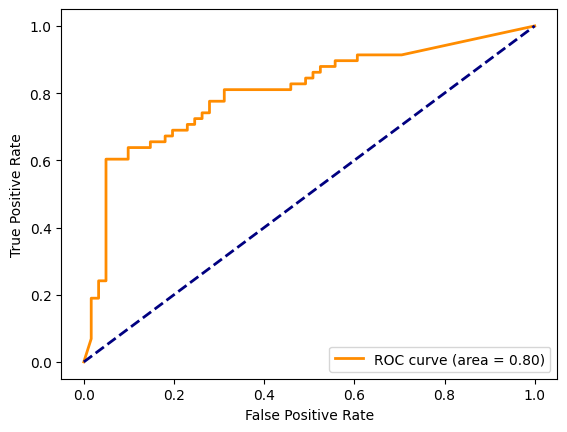

In [517]:
plot_roc_curve(knn, X_heart_train, X_heart_test, y_heart_train, y_heart_test)

##DT

In [518]:
"""##DT"""
#DT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from collections import defaultdict
from sklearn.preprocessing import label_binarize

# Convert to binary classification
heart = fetch_ucirepo(id=45)
X_heart = np.array(heart.data.features)
y_heart = np.array(heart.data.targets).ravel()
y_heart_binary = np.where(y_heart == 0, 0, 1)

# Split data into training and testing set without sklearn
def train_test_split_no_sklearn(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_len = int(len(X) * test_size)
    test_indices = indices[:test_len]
    train_indices = indices[test_len:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split_no_sklearn(X_heart, y_heart_binary, test_size=0.2)

# Define a Node class for the decision tree
class Node:
    def __init__(self, data_indices, parent):
        self.data_indices = data_indices
        self.left = None
        self.right = None
        self.split_feature = None
        self.split_value = None
        if parent:
            self.depth = parent.depth + 1
            self.num_classes = parent.num_classes
            self.data = parent.data
            self.labels = parent.labels
            class_prob = np.bincount(self.labels[data_indices], minlength=self.num_classes)
            self.class_prob = class_prob / np.sum(class_prob)

# Find the best split using a greedy approach
def greedy_test(node, cost_fn):
    best_cost = np.inf
    best_feature, best_value = None, None
    num_instances, num_features = node.data.shape
    data_sorted = np.sort(node.data[node.data_indices],axis=0)
    test_candidates = (data_sorted[1:] + data_sorted[:-1]) / 2.
    for f in range(num_features):
        data_f = node.data[node.data_indices, f]
        for test in test_candidates[:,f]:
            left_indices = node.data_indices[data_f <= test]
            right_indices = node.data_indices[data_f > test]
            if len(left_indices) == 0 or len(right_indices) == 0:
                continue
            left_cost = cost_fn(node.labels[left_indices])
            right_cost = cost_fn(node.labels[right_indices])
            num_left, num_right = left_indices.shape[0], right_indices.shape[0]
            cost = (num_left * left_cost + num_right * right_cost)/num_instances
            if cost < best_cost:
                best_cost = cost
                best_feature = f
                best_value = test
    return best_cost, best_feature, best_value

# Calculate misclassification cost
def cost_misclassification(labels):
    counts = np.bincount(labels)
    class_probs = counts / np.sum(counts)
    return 1 - np.max(class_probs)

# Calculate entropy cost
def cost_entropy(labels):
    class_probs = np.bincount(labels) / len(labels)
    class_probs = class_probs[class_probs > 0]
    return -np.sum(class_probs * np.log2(class_probs))

# Calculate gini index cost
def cost_gini_index(labels):
    class_probs = np.bincount(labels) / len(labels)
    return 1 - np.sum(np.square(class_probs))

# Define a DecisionTree class
class DecisionTree:
    def __init__(self, num_classes=None, max_depth=3, cost_fn=cost_misclassification, min_leaf_instances=1):
        self.max_depth = max_depth
        self.root = None
        self.cost_fn = cost_fn
        self.num_classes = num_classes
        self.min_leaf_instances = min_leaf_instances

    # Fit  the decision tree
    def fit(self, data, labels):
        self.data = np.array(data)
        self.labels = np.array(labels)
        if self.num_classes is None:
            self.num_classes = np.max(labels) + 1
        self.root = Node(np.arange(data.shape[0]), None)
        self.root.data = self.data
        self.root.labels = self.labels
        self.root.num_classes = self.num_classes
        self.root.depth = 0
        self._fit_tree(self.root)
        return self

    # Recursively fit the tree
    def _fit_tree(self, node):
        if node.depth == self.max_depth or len(node.data_indices) <= self.min_leaf_instances:
            return
        cost, split_feature, split_value = greedy_test(node, self.cost_fn)
        if np.isinf(cost):
            return
        test = node.data[node.data_indices,split_feature] <= split_value
        node.split_feature = split_feature
        node.split_value = split_value
        left = Node(node.data_indices[test], node)
        right = Node(node.data_indices[np.logical_not(test)], node)
        self._fit_tree(left)
        self._fit_tree(right)
        node.left = left
        node.right = right

    # Predict class labels for new data
    def predict(self, data_test):
        data_test=np.array(data_test)
        class_probs = np.zeros((data_test.shape[0], self.num_classes))
        for n, x in enumerate(data_test):
            node = self.root
            while node.left:
                if x[node.split_feature] <= node.split_value:
                    node = node.left
                else:
                    node = node.right
            class_probs[n,:] = node.class_prob
        return np.argmax(class_probs, axis=1)

    def predict_proba(self, data_test):
        class_probs = np.zeros((data_test.shape[0], self.num_classes))
        for i, x in enumerate(data_test):
            node = self.root
            while node.left:
                node = node.left if x[node.split_feature] <= node.split_value else node.right
            class_probs[i, :] = node.class_prob
        return class_probs

    def compute_feature_importances(self):
        from collections import defaultdict
        usage_counter = defaultdict(int)
        def gather_usage(node):
            if node.left and node.right:
                usage_counter[node.split_feature] += 1
                gather_usage(node.left)
                gather_usage(node.right)
        gather_usage(self.root)
        return sorted(usage_counter.items(), key=lambda x: x[1], reverse=True)


  # Encode labels to numerical without sklearn
def label_encode_no_sklearn(y):
      unique_labels = np.unique(y)
      label_mapping = {label: index for index, label in enumerate(unique_labels)}
      encoded_y = np.array([label_mapping[label] for label in y])
      return encoded_y, label_mapping

  # Calculate accuracy
def evaluate_acc(y_pred, y_true):
      return np.mean(y_pred == y_true)


# Search best depth
best_depth_heart = 0
best_acc_heart = 0
for depth in range(2, 10):
    tree_heart = DecisionTree(max_depth=depth, cost_fn=cost_gini_index)
    tree_heart.fit(X_train_heart, y_train_heart)
    y_pred_heart = tree_heart.predict(X_test_heart)
    acc_heart = evaluate_acc(y_pred_heart, y_test_heart)
    if acc_heart > best_acc_heart:
        best_acc_heart = acc_heart
        best_depth_heart = depth

print(f'Heart Disease: Best Depth = {best_depth_heart}, Best Accuracy = {best_acc_heart*100:.2f}%')


# for penguins dataset
penguin_data_file_path = "/content/drive/MyDrive/COMP551/penguins_size.csv"
penguin_data = pd.read_csv(penguin_data_file_path)
penguin_data = penguin_data.drop(columns=['island'])
penguin_data = penguin_data.dropna()
penguin_data = penguin_data[penguin_data['sex'].isin(['MALE', 'FEMALE'])]
penguin_data = pd.get_dummies(penguin_data, columns=['sex'], drop_first=True)
X_penguin = penguin_data.drop(columns=['species'])
y_penguin = penguin_data['species']
y_penguin, label_mapping = label_encode_no_sklearn(y_penguin)
X_penguin = np.array(X_penguin)
y_penguin = np.array(y_penguin)
X_train_pen, X_test_pen, y_train_pen, y_test_pen = train_test_split_no_sklearn(X_penguin, y_penguin, test_size=0.2, random_state=42)

# Search best depth on Penguin
best_depth_pen = 0
best_acc_pen = 0
for depth in range(5, 10):
    tree_pen = DecisionTree(max_depth=depth, cost_fn=cost_entropy)
    tree_pen.fit(X_train_pen, y_train_pen)
    y_pred_pen = tree_pen.predict(X_test_pen)
    acc_pen = evaluate_acc(y_pred_pen, y_test_pen)
    if acc_pen > best_acc_pen:
        best_acc_pen = acc_pen
        best_depth_pen = depth

print(f'Penguin: Best Depth = {best_depth_pen}, Best Accuracy = {best_acc_pen*100:.2f}%')

Heart Disease: Best Depth = 3, Best Accuracy = 88.33%
Penguin: Best Depth = 5, Best Accuracy = 98.48%


In [519]:
# Define three different cost functions
cost_functions = {
    "Misclassification": cost_misclassification,
    "Entropy": cost_entropy,
    "Gini": cost_gini_index
}

# Calculate the accuracy of DT on the heart disease dataset
print("Comparing different cost functions (Accuracy) for heart disease：")
for name, fn in cost_functions.items():
    dt_temp = DecisionTree(max_depth=3, cost_fn=fn)
    dt_temp.fit(X_train_heart, y_train_heart)
    y_pred_temp = dt_temp.predict(X_test_heart)
    acc_temp = evaluate_acc(y_pred_temp, y_test_heart)
    print(f"{name} => Test Accuracy: {acc_temp:.3f}")

# Calculate the accuracy of DT on the Penguin dataset
print("Comparing different cost functions (Accuracy) for Penguin：")
for name, fn in cost_functions.items():
    dt_temp = DecisionTree(max_depth=5, cost_fn=fn)
    dt_temp.fit(X_train_pen, y_train_pen)
    y_pred_temp = dt_temp.predict(X_test_pen)
    acc_temp = evaluate_acc(y_pred_temp, y_test_pen)
    print(f"{name} => Test Accuracy: {acc_temp:.3f}")


Comparing different cost functions (Accuracy) for heart disease：
Misclassification => Test Accuracy: 0.817
Entropy => Test Accuracy: 0.850
Gini => Test Accuracy: 0.883
Comparing different cost functions (Accuracy) for Penguin：
Misclassification => Test Accuracy: 1.000
Entropy => Test Accuracy: 0.985
Gini => Test Accuracy: 1.000


In [520]:
# Calculate the AUROC of DT on the heart disease dataset
print("\nComparing different cost functions (AUROC) for heart disease:")
for name, fn in cost_functions.items():
    dt_temp = DecisionTree(max_depth=best_depth_heart, cost_fn=fn)
    dt_temp.fit(X_train_heart, y_train_heart)
    y_score_temp = dt_temp.predict_proba(X_test_heart)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_heart, y_score_temp)
    roc_auc = auc(fpr, tpr)
    print(f"{name} => AUROC: {roc_auc:.3f}")

# Calculate the AUROC of DT on the penguin dataset
print("\nComparing different cost functions (AUROC) for penguin：")
y_test_bin = label_binarize(y_test_pen, classes=np.unique(y_train_pen))
for name, cost_fn in cost_functions.items():
    dt_model = DecisionTree(max_depth=best_depth_pen, cost_fn=cost_fn)
    dt_model.fit(X_train_pen, y_train_pen)

    y_score = dt_model.predict_proba(X_test_pen)

    auc_scores = []
    for i in range(y_test_bin.shape[1]):
      fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
      auc_scores.append(auc(fpr, tpr))

    avg_auc = np.mean(auc_scores)
    print(f"{name} => AUROC (Penguin): {avg_auc:.3f}")



Comparing different cost functions (AUROC) for heart disease:
Misclassification => AUROC: 0.838
Entropy => AUROC: 0.900
Gini => AUROC: 0.935

Comparing different cost functions (AUROC) for penguin：
Misclassification => AUROC (Penguin): 1.000
Entropy => AUROC (Penguin): 0.983
Gini => AUROC (Penguin): 1.000


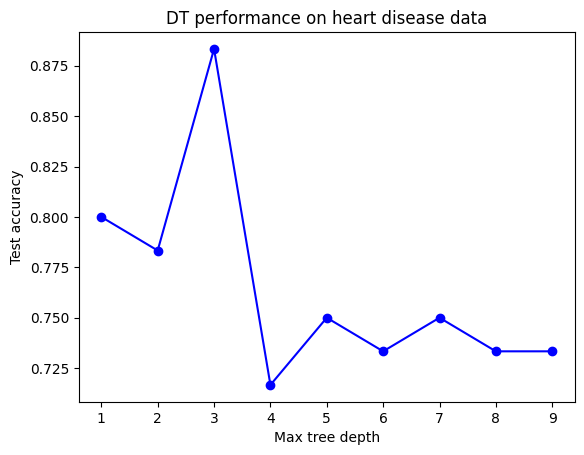

In [521]:
# DT performance on heart disease data
depths = list(range(1, 10))
accs_heart = []

for depth in depths:
    tree_heart = DecisionTree(max_depth=depth, cost_fn=cost_gini_index)
    tree_heart.fit(X_train_heart, y_train_heart)
    y_pred_heart = tree_heart.predict(X_test_heart)
    acc_heart = evaluate_acc(y_pred_heart, y_test_heart)
    accs_heart.append(acc_heart)

plt.plot(depths, accs_heart, marker='o', color='b')
plt.xlabel("Max tree depth")
plt.ylabel("Test accuracy")
plt.title("DT performance on heart disease data")
plt.show()

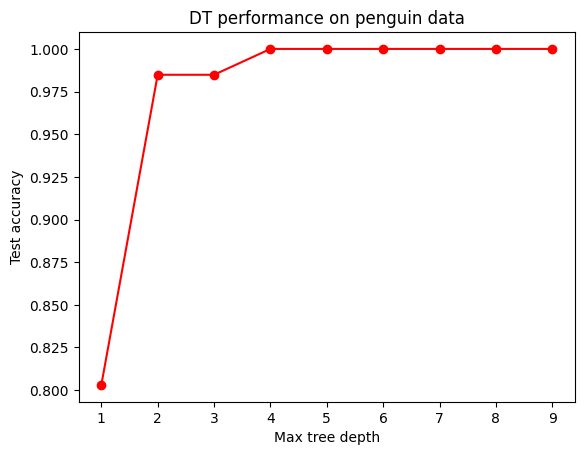

In [522]:
# DT performance on penguin data
depths = list(range(1, 10))
accs_penguin = []

for depth in depths:
    tree_penguin = DecisionTree(max_depth=depth, cost_fn=cost_gini_index)
    tree_penguin.fit(X_train_pen, y_train_pen)
    y_pred_penguin = tree_penguin.predict(X_test_pen)
    acc_penguin = evaluate_acc(y_pred_penguin, y_test_pen)
    accs_penguin.append(acc_penguin)

plt.plot(depths, accs_penguin, marker='o', color='r')
plt.xlabel("Max tree depth")
plt.ylabel("Test accuracy")
plt.title("DT performance on penguin data")
plt.show()

In [523]:
# Retrain final DT for Heart with best depth
tree_heart = DecisionTree(max_depth=best_depth_heart, cost_fn=cost_gini_index)
tree_heart.fit(X_train_heart, y_train_heart)
feat_importance = tree_heart.compute_feature_importances()
print("DT feature usage count for heart disease:", feat_importance)

dt_penguin = DecisionTree(max_depth=best_depth_pen, cost_fn=cost_gini_index)
dt_penguin.fit(X_train_pen, y_train_pen)
feat_imp_penguin = dt_penguin.compute_feature_importances()
print("DT feature usage count for penguin:", feat_imp_penguin[:5])

DT feature usage count for heart disease: [(12, 2), (11, 2), (2, 1), (0, 1), (3, 1)]
DT feature usage count for penguin: [(0, 17), (1, 4), (2, 1), (3, 1), (4, 1)]


In [524]:
# Top 5 Features by Mean Difference heart disease
heart_columns = [f"heart_feat_{i}" for i in range(X_heart.shape[1])]
df_heart = pd.DataFrame(X_heart, columns=heart_columns)
df_heart['target'] = np.where(y_heart == 0, 0, 1)

# Calculate target=0 target=1 mean
means_by_target = df_heart.groupby('target').mean()
neg_mean = means_by_target.loc[0]
pos_mean = means_by_target.loc[1]

# Calculate difference and arrange
diff_squared = (pos_mean - neg_mean) ** 2
top5_heart = diff_squared.sort_values(ascending=False).head(5)
print("\n[Heart Disease] Top 5 Features by Mean Difference:")
print(top5_heart)


[Heart Disease] Top 5 Features by Mean Difference:
heart_feat_7    365.53830
heart_feat_4     78.04974
heart_feat_3     28.28480
heart_feat_0     16.32591
heart_feat_12     4.17399
dtype: float64


In [525]:
# Top 5 Features by Mean Difference penguin
y_penguin = penguin_data['species']
X_penguin = penguin_data.drop(columns=['species'])

# Calculate the mean for different species
means_by_species = X_penguin.groupby(y_penguin).mean()
species_keys = means_by_species.index
mean_diff_results = {}

for i in range(len(species_keys)):
    for j in range(i + 1, len(species_keys)):
        species_1 = species_keys[i]
        species_2 = species_keys[j]
        diff_squared = (means_by_species.loc[species_1] - means_by_species.loc[species_2]) ** 2
        mean_diff_results[f"{species_1} vs {species_2}"] = diff_squared

        print(f"\n[{species_1} vs {species_2}] Top 5 features by mean difference:")
        print(diff_squared.sort_values(ascending=False).head(5))


[Adelie vs Chinstrap] Top 5 features by mean difference:
body_mass_g         724.89379
culmen_length_mm    100.19712
flipper_length_mm    32.72743
culmen_depth_mm       0.00538
sex_MALE              0.00000
dtype: float64

[Adelie vs Gentoo] Top 5 features by mean difference:
body_mass_g         1921751.69719
flipper_length_mm       736.17551
culmen_length_mm         76.45919
culmen_depth_mm          11.22667
sex_MALE                  0.00016
dtype: float64

[Chinstrap vs Gentoo] Top 5 features by mean difference:
body_mass_g         1847828.99557
flipper_length_mm       458.46367
culmen_depth_mm          11.72343
culmen_length_mm          1.60214
sex_MALE                  0.00016
dtype: float64


In [526]:
penguin_columns = list(penguin_data.drop(columns=['species']).columns)
top5_dt_features_penguin = [penguin_columns[f[0]] for f in feat_imp_penguin[:5]]
print("\n[Penguin] Top 5 Features by DT Importance:")
print(top5_dt_features_penguin)


[Penguin] Top 5 Features by DT Importance:
['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_MALE']


In [527]:
top5_dt_features = feat_importance[:5]
# DT
dt_top5_features = [heart_columns[f[0]] for f in top5_dt_features]

# Mean difference top 5
top5_heart_features = top5_heart.index.tolist()

# Compare
print("\n[Heart disease] Comparison of Feature Selection Methods:")
print(f"Top 5 Features by DT Importance: {dt_top5_features}")
print(f"Top 5 Features by Mean Difference: {top5_heart_features}")

# find difference
dt_unique = set(dt_top5_features) - set(top5_heart_features)
mean_diff_unique = set(top5_heart_features) - set(dt_top5_features)

print(f"\nFeatures only in DT importance: {dt_unique}")
print(f"Features only in mean difference: {mean_diff_unique}")


[Heart disease] Comparison of Feature Selection Methods:
Top 5 Features by DT Importance: ['heart_feat_12', 'heart_feat_11', 'heart_feat_2', 'heart_feat_0', 'heart_feat_3']
Top 5 Features by Mean Difference: ['heart_feat_7', 'heart_feat_4', 'heart_feat_3', 'heart_feat_0', 'heart_feat_12']

Features only in DT importance: {'heart_feat_2', 'heart_feat_11'}
Features only in mean difference: {'heart_feat_4', 'heart_feat_7'}


In [528]:
# Compare difference for peguin
top5_dt_features_penguin = feat_imp_penguin[:5]
penguin_columns = list(X_penguin.columns)

dt_top5_features_penguin = [penguin_columns[f[0]] for f in top5_dt_features_penguin]

mean_diff_top5_penguin = {}

for i in range(len(species_keys)):
    for j in range(i + 1, len(species_keys)):
        species_1 = species_keys[i]
        species_2 = species_keys[j]
        diff_squared = (means_by_species.loc[species_1] - means_by_species.loc[species_2]) ** 2
        mean_diff_top5_penguin[f"{species_1} vs {species_2}"] = diff_squared.sort_values(ascending=False).head(5)

mean_diff_features_penguin = set()
for key, diff in mean_diff_top5_penguin.items():
    mean_diff_features_penguin.update(diff.index.tolist())

print("\n[Penguin] Comparison of Feature Selection Methods:")
print(f"Top 5 Features by DT Importance: {dt_top5_features_penguin}")
print(f"Top 5 Features by Mean Difference: {list(mean_diff_features_penguin)}")

dt_unique_penguin = set(dt_top5_features_penguin) - mean_diff_features_penguin
mean_diff_unique_penguin = mean_diff_features_penguin - set(dt_top5_features_penguin)

print(f"\nFeatures only in DT importance (Penguin): {dt_unique_penguin}")
print(f"Features only in mean difference (Penguin): {mean_diff_unique_penguin}")



[Penguin] Comparison of Feature Selection Methods:
Top 5 Features by DT Importance: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_MALE']
Top 5 Features by Mean Difference: ['culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_MALE', 'culmen_length_mm']

Features only in DT importance (Penguin): set()
Features only in mean difference (Penguin): set()


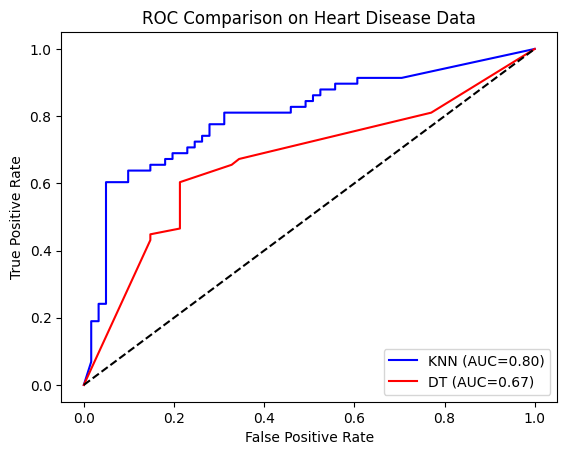

In [529]:
def plot_roc_comparison(X_test, y_test, knn, dt, dataset_name="Heart"):
    # KNN
    y_score_knn = knn.predict(X_test, use_probability=True)
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
    auc_knn = auc(fpr_knn, tpr_knn)

    # DT
    y_score_dt = dt.predict_proba(X_test)[:, 1]
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
    auc_dt = auc(fpr_dt, tpr_dt)

    # plot
    plt.figure()
    plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})", color='blue')
    plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC={auc_dt:.2f})", color='red')
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Comparison on {dataset_name} Data")
    plt.legend(loc='lower right')
    plt.show()

# train KNN and DT
dt = DecisionTree(max_depth=5, cost_fn=cost_gini_index)
dt.fit(X_heart_train, y_heart_train)

knn.fit(X_heart_train, y_heart_train)

# plot
plot_roc_comparison(X_heart_test, y_heart_test, knn, dt, "Heart Disease")